<a href="https://colab.research.google.com/github/lizbethQCC/2024/blob/main/Act_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#0f1117',
    'savefig.facecolor': '#0f1117',
    'axes.edgecolor': '#3a3f4b',
    'axes.labelcolor': '#e6e6e6',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'text.color': '#e6e6e6',
    'grid.color': '#2a2f3a',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.frameon': True,
    'legend.facecolor': '#1a1d26',
    'legend.edgecolor': '#3a3f4b',
    'figure.dpi': 110,
})

# Paletas personalizadas
PALETTE = ['#00d4ff', '#ff6b9d', '#ffd93d', '#6bcb77', '#c77dff',
           '#ff9f1c', '#4ecdc4', '#f72585']

def styled_title(ax, title, subtitle=None):
    """Título con subtítulo elegante."""
    ax.set_title(title, fontsize=14, fontweight='bold', color='#ffffff', pad=14)
    if subtitle:
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
                ha='center', va='bottom', fontsize=9, color='#8a93a6', style='italic')

Eigenfaces con olivetti_faces.npy

Dataset cargado: 400 imágenes, 4096 dimensiones
Personas únicas: 40

✅ Precisión: 98.00%  |  Tiempo entrenamiento: 0.052s

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15

/tmp/ipykernel_552/418996460.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


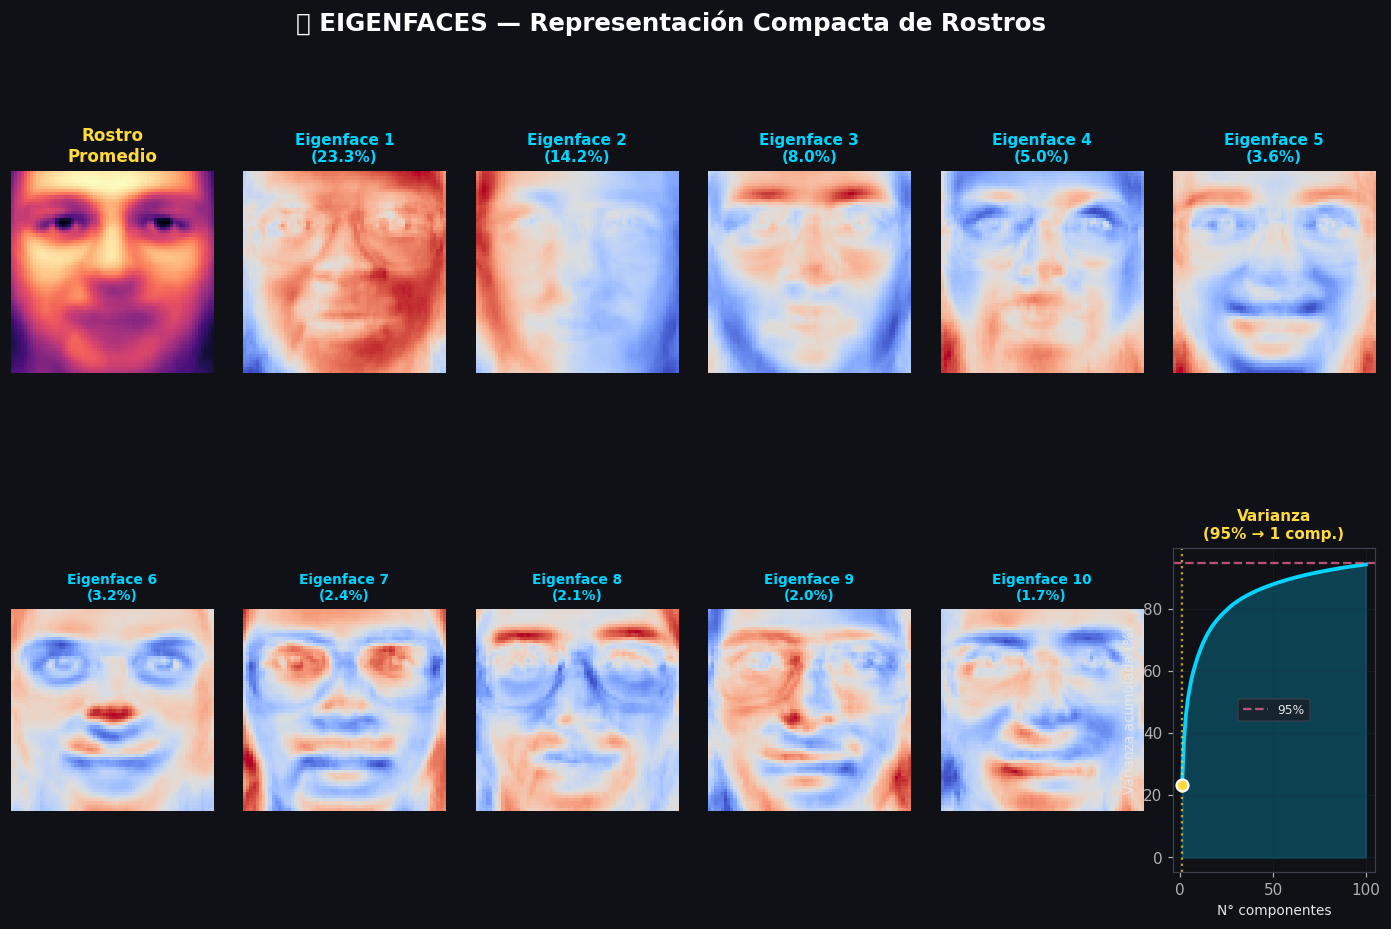

/tmp/ipykernel_552/418996460.py:130: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


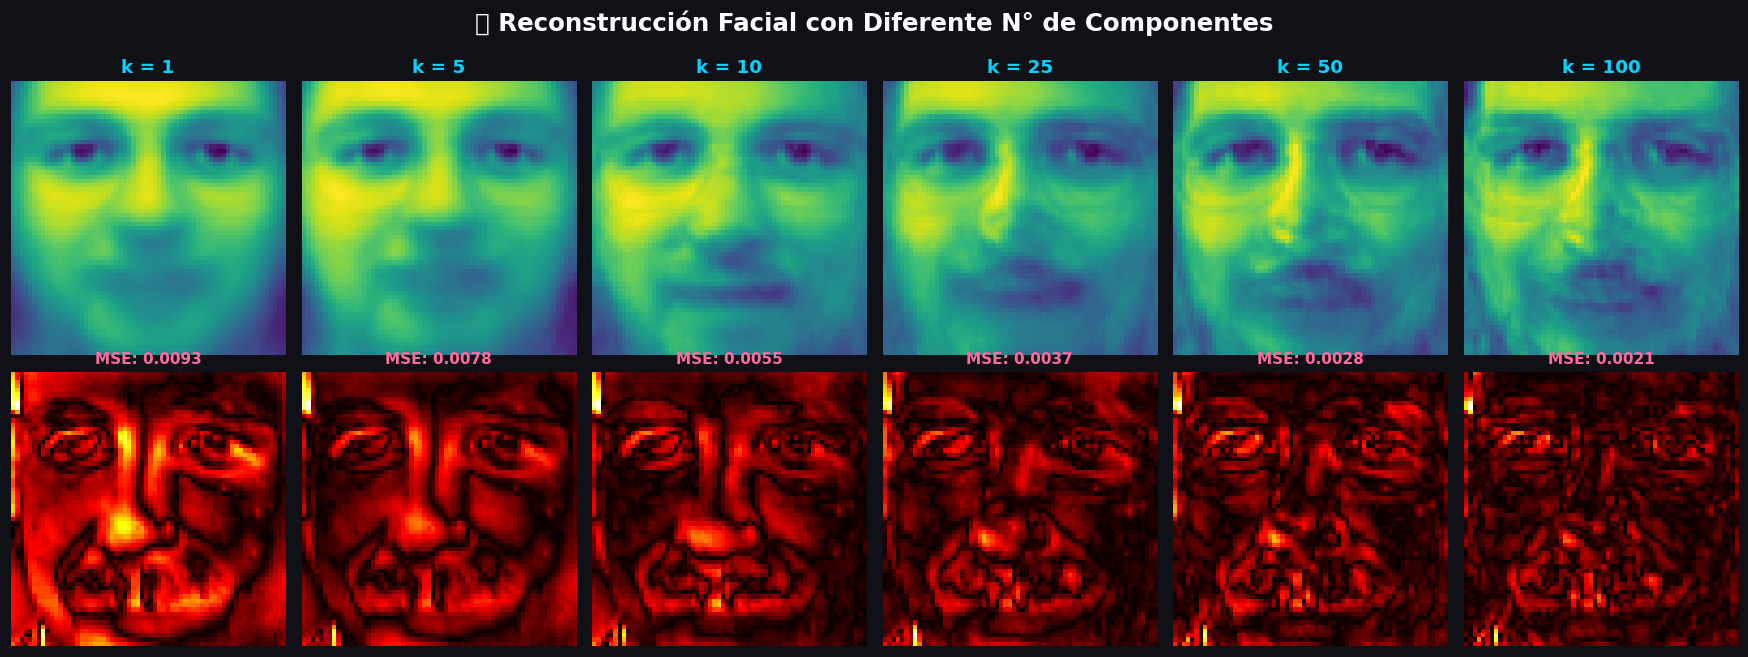

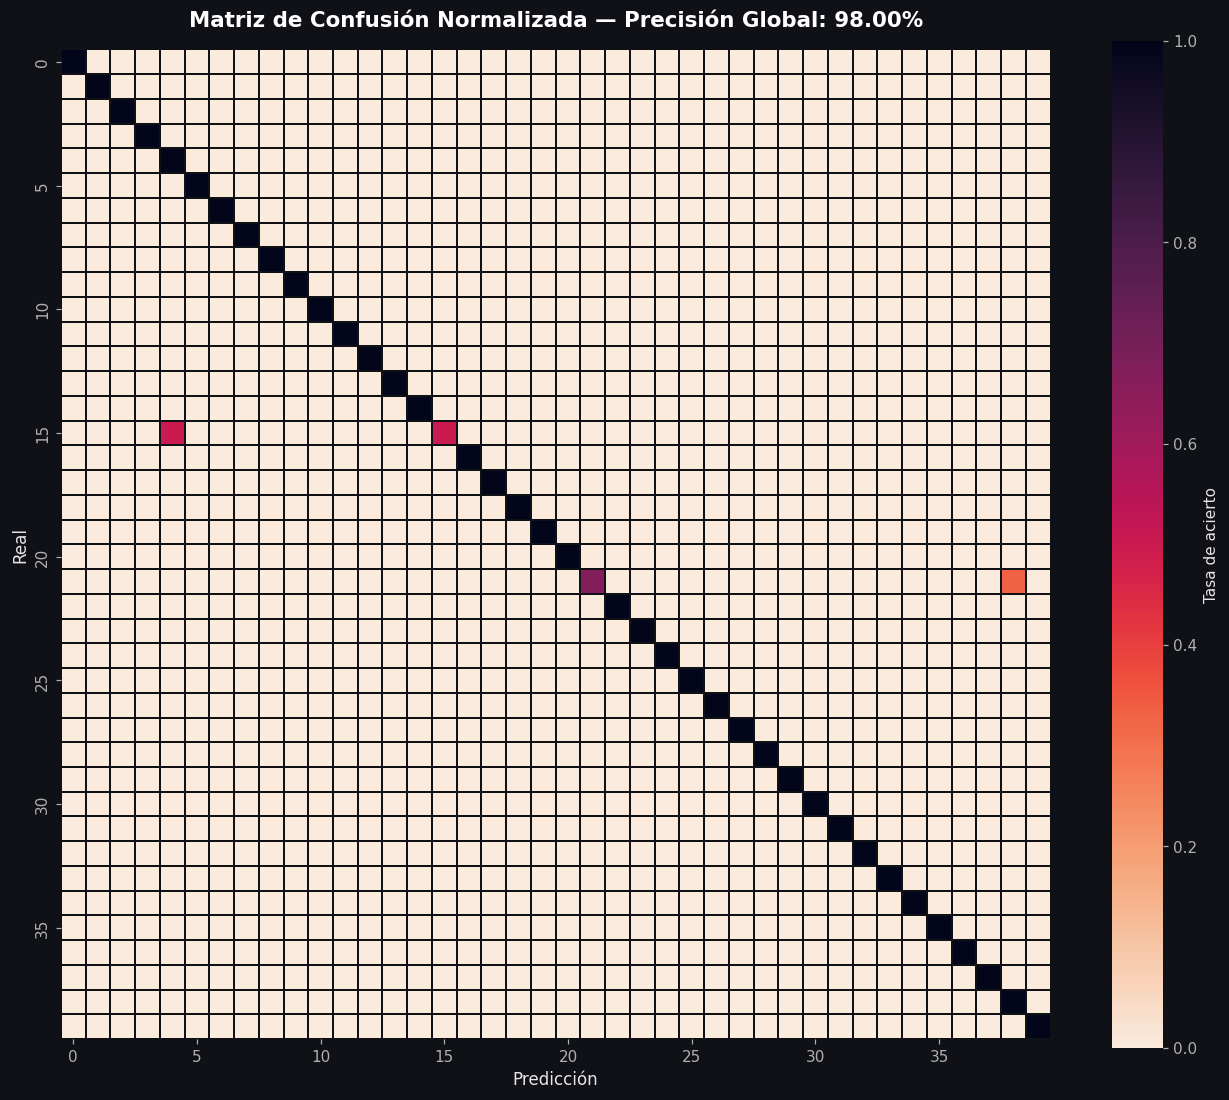

In [4]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import time

# ==================== CARGA DEL DATASET ====================
# Asumimos que olivetti_faces.npy tiene shape (400, 4096) o (400, 64, 64)
faces_raw = np.load('olivetti_faces.npy', allow_pickle=True)

# Normalizar shape
if faces_raw.ndim == 3:
    X = faces_raw.reshape(faces_raw.shape[0], -1)
    images = faces_raw
else:
    X = faces_raw
    images = faces_raw.reshape(-1, 64, 64)

# Etiquetas: 40 personas × 10 imágenes = 400
y = np.repeat(np.arange(40), 10)

# Normalizar a [0,1]
X = (X - X.min()) / (X.max() - X.min())

print(f"Dataset cargado: {X.shape[0]} imágenes, {X.shape[1]} dimensiones")
print(f"Personas únicas: {len(np.unique(y))}")

# ==================== SPLIT ====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ==================== PCA (EIGENFACES) ====================
n_components = 100
pca = PCA(n_components=n_components, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# ==================== CLASIFICADOR SVM ====================
svm = SVC(kernel='rbf', C=10, gamma=0.001)
t0 = time.time()
svm.fit(X_train_pca, y_train)
train_time = time.time() - t0

y_pred = svm.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Precisión: {acc*100:.2f}%  |  Tiempo entrenamiento: {train_time:.3f}s")
print("\n" + classification_report(y_test, y_pred, zero_division=0))

# ==================== FIGURA 1: EIGENFACES ====================
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.15)

# Rostro promedio
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean.imshow(pca.mean_.reshape(64, 64), cmap='magma')
ax_mean.set_title('Rostro\nPromedio', fontsize=11, color='#ffd93d')
ax_mean.axis('off')
for spine in ax_mean.spines.values():
    spine.set_visible(False)

# Primeras 5 eigenfaces
for i in range(5):
    ax = fig.add_subplot(gs[0, i + 1])
    ef = pca.components_[i].reshape(64, 64)
    im = ax.imshow(ef, cmap='coolwarm')
    ax.set_title(f'Eigenface {i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)',
                 fontsize=10, color='#00d4ff')
    ax.axis('off')

# Eigenfaces 6-11
for i in range(5, 11):
    ax = fig.add_subplot(gs[1, i - 5])
    ef = pca.components_[i].reshape(64, 64)
    ax.imshow(ef, cmap='coolwarm')
    ax.set_title(f'Eigenface {i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)',
                 fontsize=9, color='#00d4ff')
    ax.axis('off')

# Panel de varianza explicada
ax_var = fig.add_subplot(gs[1, 5])
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax_var.plot(range(1, len(cumvar)+1), cumvar, color='#00d4ff', linewidth=2.5)
ax_var.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.25, color='#00d4ff')
ax_var.axhline(95, color='#ff6b9d', linestyle='--', alpha=0.7, label='95%')
idx_95 = np.argmax(cumvar >= 95) + 1
ax_var.axvline(idx_95, color='#ffd93d', linestyle=':', alpha=0.7)
ax_var.scatter([idx_95], [cumvar[idx_95-1]], color='#ffd93d', s=60, zorder=5,
               edgecolor='white', linewidth=1.5)
ax_var.set_xlabel('N° componentes', fontsize=9)
ax_var.set_ylabel('Varianza acumulada (%)', fontsize=9)
ax_var.set_title(f'Varianza\n(95% → {idx_95} comp.)', fontsize=10, color='#ffd93d')
ax_var.grid(True, alpha=0.3)
ax_var.legend(fontsize=8)

fig.suptitle('🎭 EIGENFACES — Representación Compacta de Rostros',
             fontsize=16, fontweight='bold', color='#ffffff', y=0.98)
plt.tight_layout()
plt.show()

# ==================== FIGURA 2: RECONSTRUCCIÓN ====================
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
k_values = [1, 5, 10, 25, 50, 100]
test_face = X_test[0]

def reconstruct(face_vector, k):
    comp = pca.transform(face_vector.reshape(1, -1))[:, :k]
    pad = np.zeros((1, pca.n_components_ - k))
    reduced = np.c_[comp, pad]
    return pca.inverse_transform(reduced).reshape(64, 64)

# Fila superior: reconstrucciones
for i, k in enumerate(k_values):
    axes[0, i].imshow(reconstruct(test_face, k), cmap='viridis')
    axes[0, i].set_title(f'k = {k}', fontsize=12, color='#00d4ff')
    axes[0, i].axis('off')

# Fila inferior: diferencia con original
orig = test_face.reshape(64, 64)
for i, k in enumerate(k_values):
    recon = reconstruct(test_face, k)
    diff = np.abs(orig - recon)
    im = axes[1, i].imshow(diff, cmap='hot')
    mse = np.mean(diff**2)
    axes[1, i].set_title(f'MSE: {mse:.4f}', fontsize=10, color='#ff6b9d')
    axes[1, i].axis('off')

fig.suptitle('🔍 Reconstrucción Facial con Diferente N° de Componentes',
             fontsize=16, fontweight='bold', color='#ffffff', y=1.00)
plt.tight_layout()
plt.show()

# ==================== FIGURA 3: MATRIZ DE CONFUSIÓN ====================
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, cmap='rocket_r', cbar_kws={'label': 'Tasa de acierto'},
            square=True, linewidths=0.3, linecolor='#0f1117', ax=ax,
            xticklabels=5, yticklabels=5)
ax.set_title(f'Matriz de Confusión Normalizada — Precisión Global: {acc*100:.2f}%',
             fontsize=14, fontweight='bold', color='#ffffff', pad=15)
ax.set_xlabel('Predicción', fontsize=11, color='#e6e6e6')
ax.set_ylabel('Real', fontsize=11, color='#e6e6e6')
plt.tight_layout()
plt.show()

NMF para Recomendación de Artículos

Matriz documento-término: (25, 153)
Error de reconstrucción NMF: 4.2138


/tmp/ipykernel_552/3600954723.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


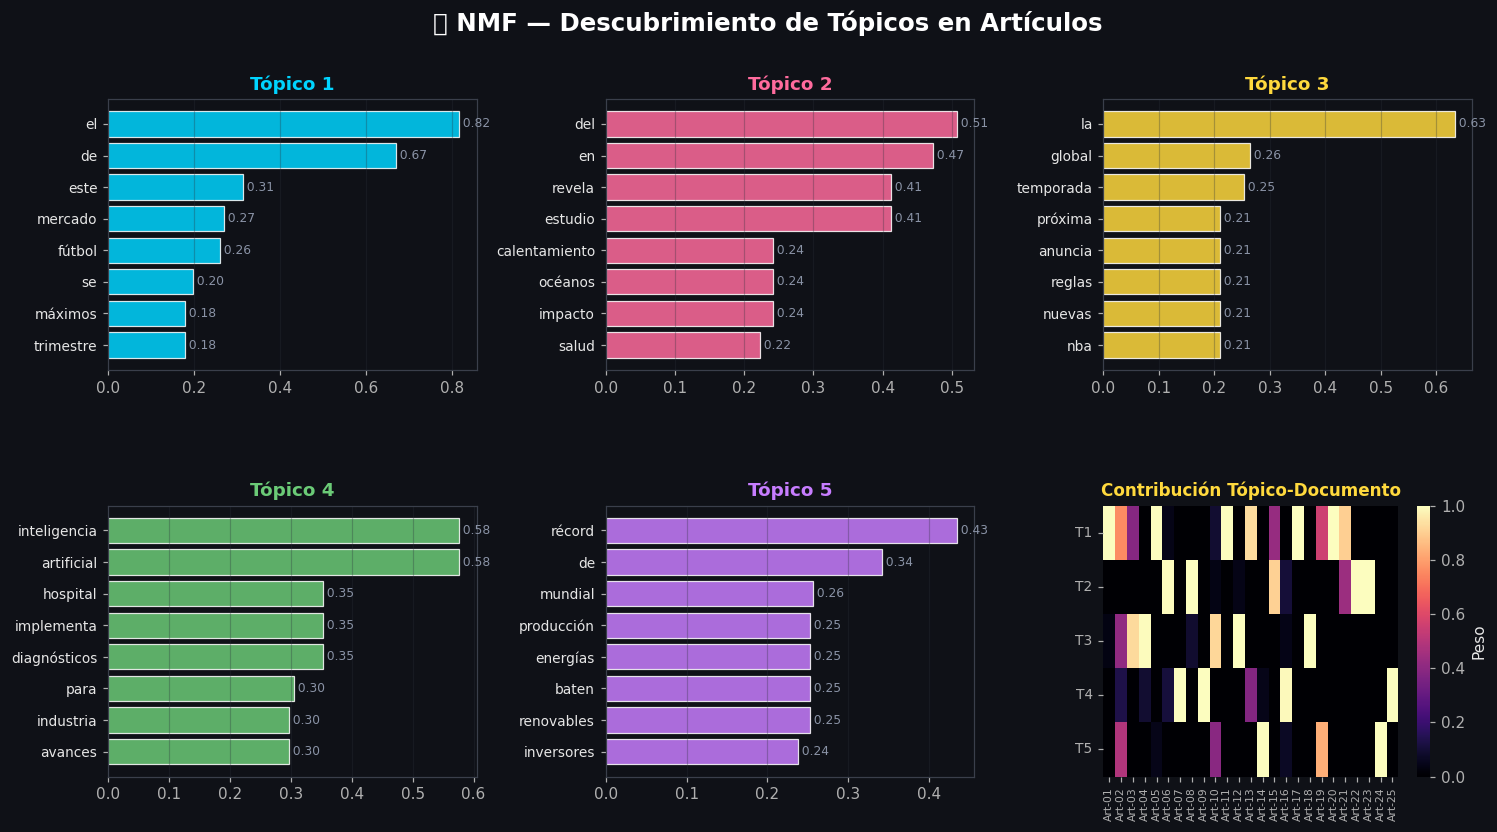

/tmp/ipykernel_552/3600954723.py:141: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


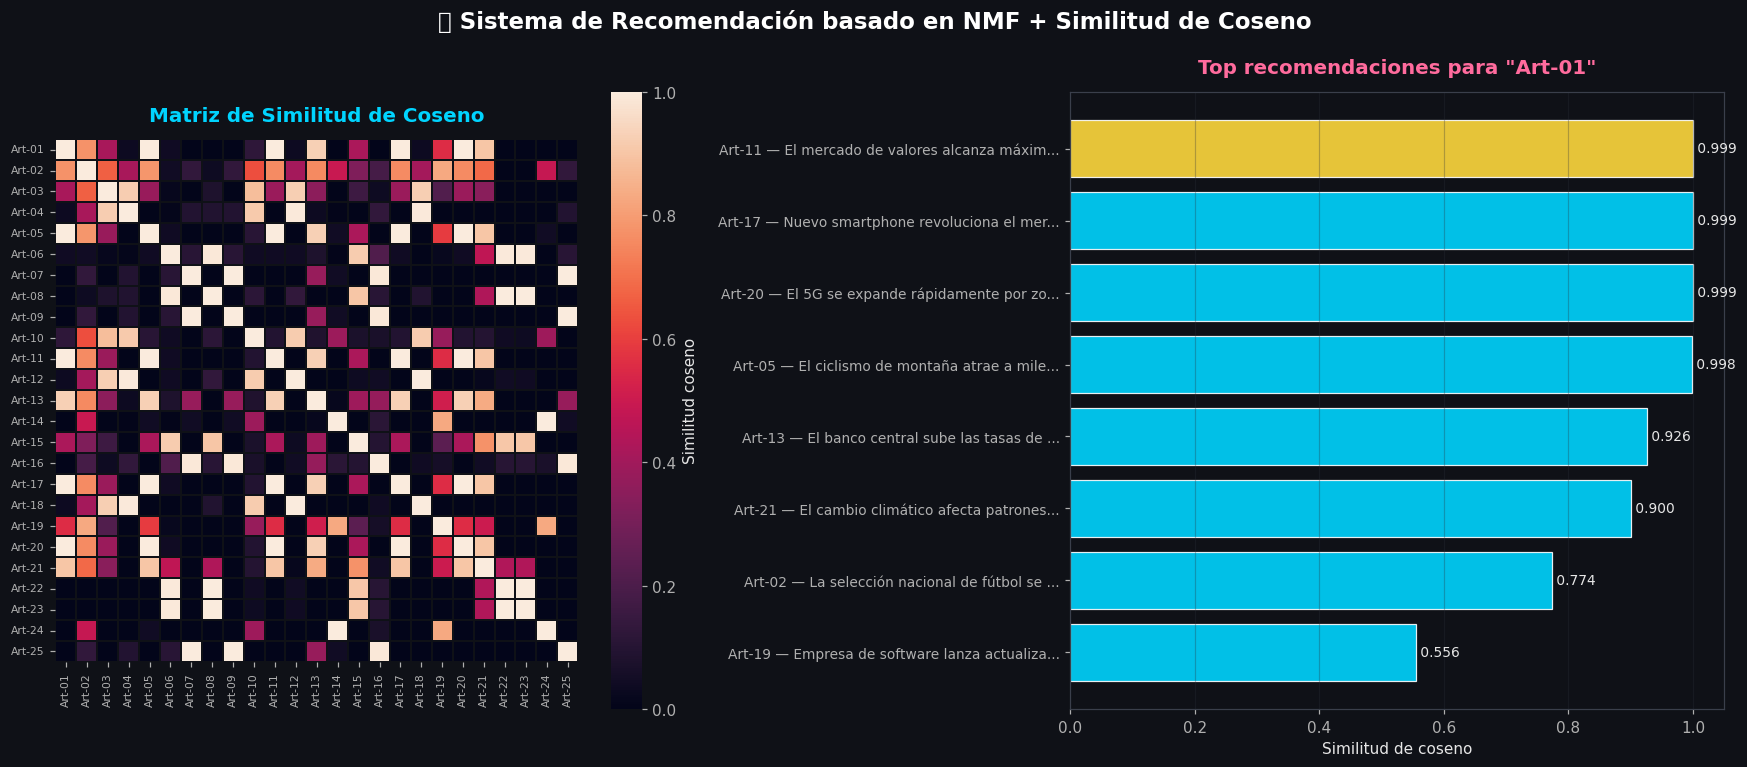


📌 Recomendaciones para 'Art-01':
  → Art-11  (sim=0.999)  |  El mercado de valores alcanza máximos históricos este trimes...
  → Art-17  (sim=0.999)  |  Nuevo smartphone revoluciona el mercado con pantalla plegabl...
  → Art-20  (sim=0.999)  |  El 5G se expande rápidamente por zonas rurales...
  → Art-05  (sim=0.998)  |  El ciclismo de montaña atrae a miles de aficionados este año...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import pandas as pd

# ==================== CORPUS DE EJEMPLO ====================
articles = [
    # Deportes
    "El equipo de fútbol ganó el campeonato tras una temporada histórica",
    "La selección nacional de fútbol se prepara para el mundial de Qatar",
    "El tenista español gana su tercer Grand Slam de la temporada",
    "La NBA anuncia nuevas reglas para la próxima temporada",
    "El ciclismo de montaña atrae a miles de aficionados este año",
    # Salud
    "Nuevo tratamiento médico muestra resultados prometedores en cáncer",
    "Investigadores desarrollan vacuna contra enfermedad infecciosa",
    "Estudio revela beneficios del ejercicio en la salud mental",
    "Hospital implementa inteligencia artificial para diagnósticos",
    "La OMS alerta sobre aumento de casos de diabetes global",
    # Economía
    "El mercado de valores alcanza máximos históricos este trimestre",
    "La bolsa cae ante incertidumbre económica global",
    "El banco central sube las tasas de interés para controlar inflación",
    "Startup tecnológica recibe financiamiento récord de inversores",
    "El desempleo disminuye según cifras oficiales del gobierno",
    # Tecnología
    "Avances en inteligencia artificial transforman la industria tecnológica",
    "Nuevo smartphone revoluciona el mercado con pantalla plegable",
    "La computación cuántica promete resolver problemas complejos",
    "Empresa de software lanza actualización con mejoras de seguridad",
    "El 5G se expande rápidamente por zonas rurales",
    # Clima
    "El cambio climático afecta patrones de lluvia en el hemisferio sur",
    "Estudio revela impacto del calentamiento global en océanos",
    "Sequía extrema afecta cultivos en varias regiones del país",
    "Energías renovables baten récord de producción mundial",
    "Activistas exigen políticas más estrictas contra contaminación",
]

titles = [f"Art-{i+1:02d}" for i in range(len(articles))]

# ==================== VECTORIZACIÓN ====================
tfidf = TfidfVectorizer(max_df=0.95, min_df=1, stop_words=None)
dtm = tfidf.fit_transform(articles)
print(f"Matriz documento-término: {dtm.shape}")

# ==================== NMF ====================
n_topics = 5
nmf = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=500)
nmf_features = nmf.fit_transform(dtm)
print(f"Error de reconstrucción NMF: {nmf.reconstruction_err_:.4f}")

# Normalizar para similitud de coseno
norm_features = normalize(nmf_features)
df = pd.DataFrame(norm_features, index=titles,
                  columns=[f'Tópico {i+1}' for i in range(n_topics)])

# ==================== RECOMENDADOR ====================
def recomendar(titulo, top_n=4):
    sims = df.dot(df.loc[titulo]).drop(titulo)
    return sims.nlargest(top_n)

# ==================== FIGURA 1: TÓPICOS ====================
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

# Términos top por tópico
def top_words(topic_idx, n=8):
    words = tfidf.get_feature_names_out()
    idx = nmf.components_[topic_idx].argsort()[::-1][:n]
    return [words[i] for i in idx], nmf.components_[topic_idx][idx]

topic_colors = ['#00d4ff', '#ff6b9d', '#ffd93d', '#6bcb77', '#c77dff']

for i in range(n_topics):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])
    words, weights = top_words(i)
    y_pos = np.arange(len(words))
    bars = ax.barh(y_pos, weights, color=topic_colors[i], alpha=0.85,
                   edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9, color='#e6e6e6')
    ax.invert_yaxis()
    ax.set_title(f'Tópico {i+1}', fontsize=12, color=topic_colors[i])
    ax.grid(axis='x', alpha=0.3)
    for bar in bars:
        w = bar.get_width()
        ax.text(w, bar.get_y() + bar.get_height()/2, f' {w:.2f}',
                va='center', fontsize=8, color='#8a93a6')

# Heatmap de contribución documento-tópico
ax_heat = fig.add_subplot(gs[1, 2])
sns.heatmap(df.T, cmap='magma', cbar_kws={'label': 'Peso'}, ax=ax_heat,
            xticklabels=True, yticklabels=[f'T{i+1}' for i in range(n_topics)])
ax_heat.set_title('Contribución Tópico-Documento', fontsize=11, color='#ffd93d')
ax_heat.tick_params(axis='x', labelsize=7, rotation=90)
ax_heat.tick_params(axis='y', labelsize=9, rotation=0)

fig.suptitle('📰 NMF — Descubrimiento de Tópicos en Artículos',
             fontsize=16, fontweight='bold', color='#ffffff', y=0.98)
plt.tight_layout()
plt.show()

# ==================== FIGURA 2: SIMILITUD DE COSENO ====================
sim_matrix = df.dot(df.T)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap
mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)
sns.heatmap(sim_matrix, cmap='rocket', ax=axes[0], square=True,
            linewidths=0.2, linecolor='#0f1117',
            cbar_kws={'label': 'Similitud coseno'},
            xticklabels=True, yticklabels=True)
axes[0].set_title('Matriz de Similitud de Coseno', fontsize=13,
                  color='#00d4ff', pad=12)
axes[0].tick_params(labelsize=7)

# Ejemplo de recomendación
query = 'Art-01'
sims = recomendar(query, top_n=8)
colors = ['#ffd93d' if i == 0 else '#00d4ff' for i in range(len(sims))]
bars = axes[1].barh(range(len(sims)), sims.values, color=colors,
                     edgecolor='white', linewidth=0.8, alpha=0.9)
axes[1].set_yticks(range(len(sims)))
axes[1].set_yticklabels([f'{t} — {articles[titles.index(t)][:35]}...'
                         if t != query else f'{t} (actual)'
                         for t in sims.index], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Similitud de coseno', fontsize=10)
axes[1].set_title(f'Top recomendaciones para "{query}"', fontsize=13,
                  color='#ff6b9d', pad=12)
axes[1].grid(axis='x', alpha=0.3)
for bar, v in zip(bars, sims.values):
    axes[1].text(v, bar.get_y() + bar.get_height()/2, f' {v:.3f}',
                 va='center', fontsize=9, color='#e6e6e6')

fig.suptitle('🎯 Sistema de Recomendación basado en NMF + Similitud de Coseno',
             fontsize=15, fontweight='bold', color='#ffffff', y=0.99)
plt.tight_layout()
plt.show()

# Demo
print("\n📌 Recomendaciones para 'Art-01':")
for t, s in recomendar('Art-01').items():
    print(f"  → {t}  (sim={s:.3f})  |  {articles[titles.index(t)][:60]}...")

 Detección de Anomalías en Series Temporales con Ensemble

       EVALUACIÓN DEL ENSEMBLE DE ANOMALÍAS

Isolation Forest
  F1: 0.100 | Precisión: 0.100 | Recall: 0.100 | AUC: 0.708

Local Outlier Factor
  F1: 0.150 | Precisión: 0.150 | Recall: 0.150 | AUC: 0.804

One-Class SVM
  F1: 0.200 | Precisión: 0.200 | Recall: 0.200 | AUC: 0.828

🎯 ENSEMBLE
  F1: 0.125 | Precisión: 0.125 | Recall: 0.125 | AUC: 0.818


/tmp/ipykernel_552/1209469065.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


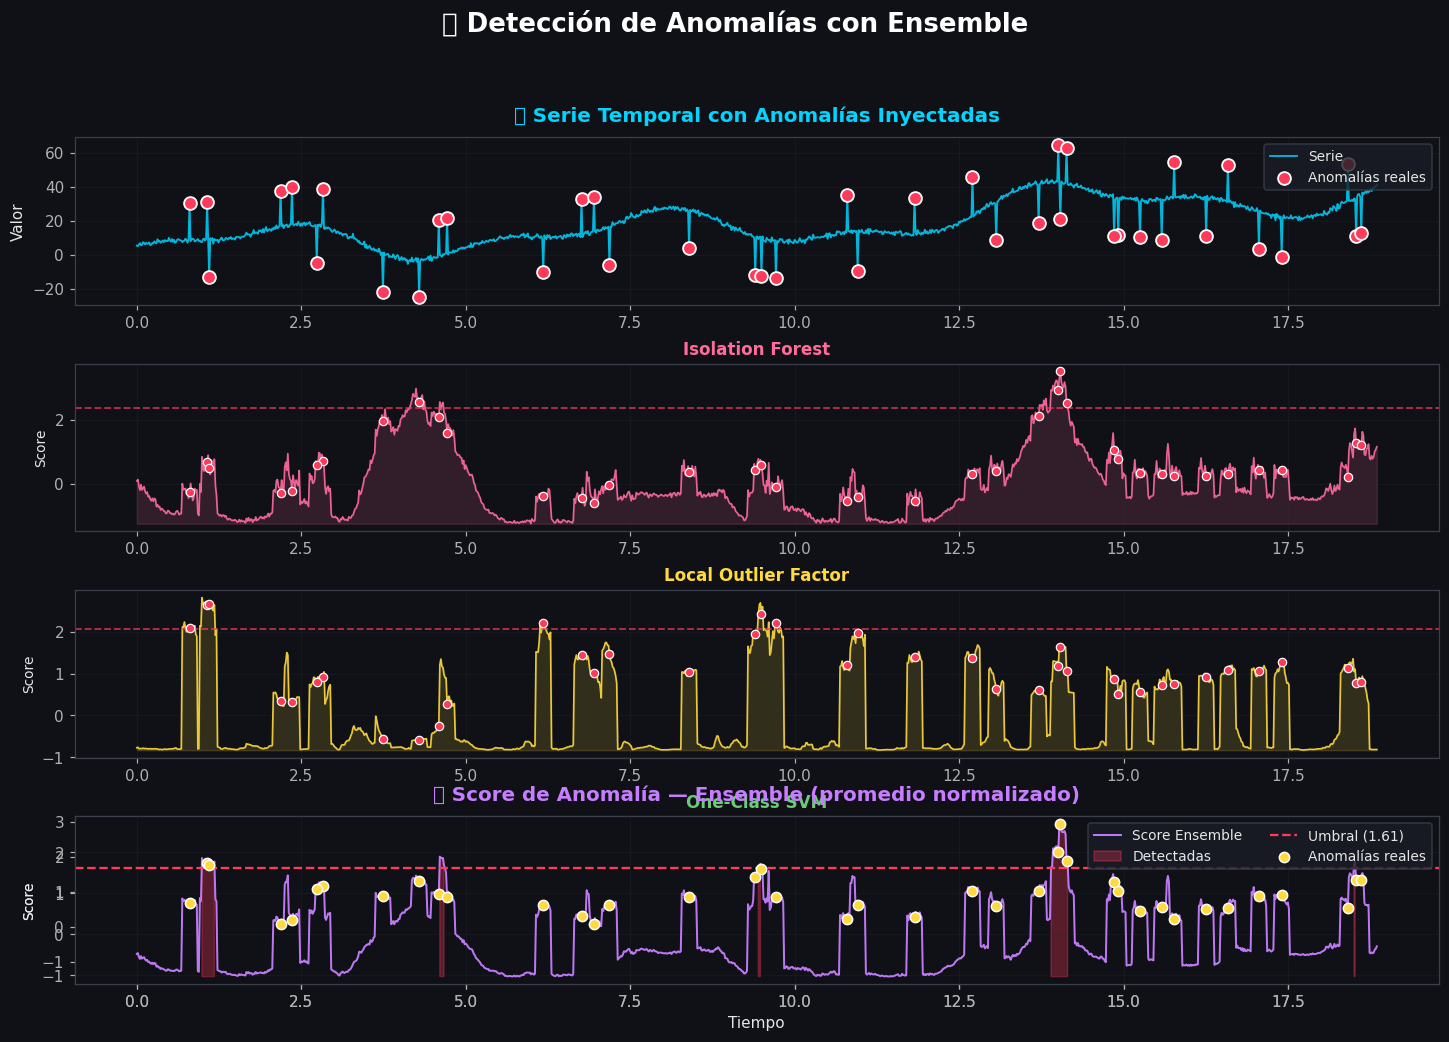

/tmp/ipykernel_552/1209469065.py:214: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1209469065.py:214: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


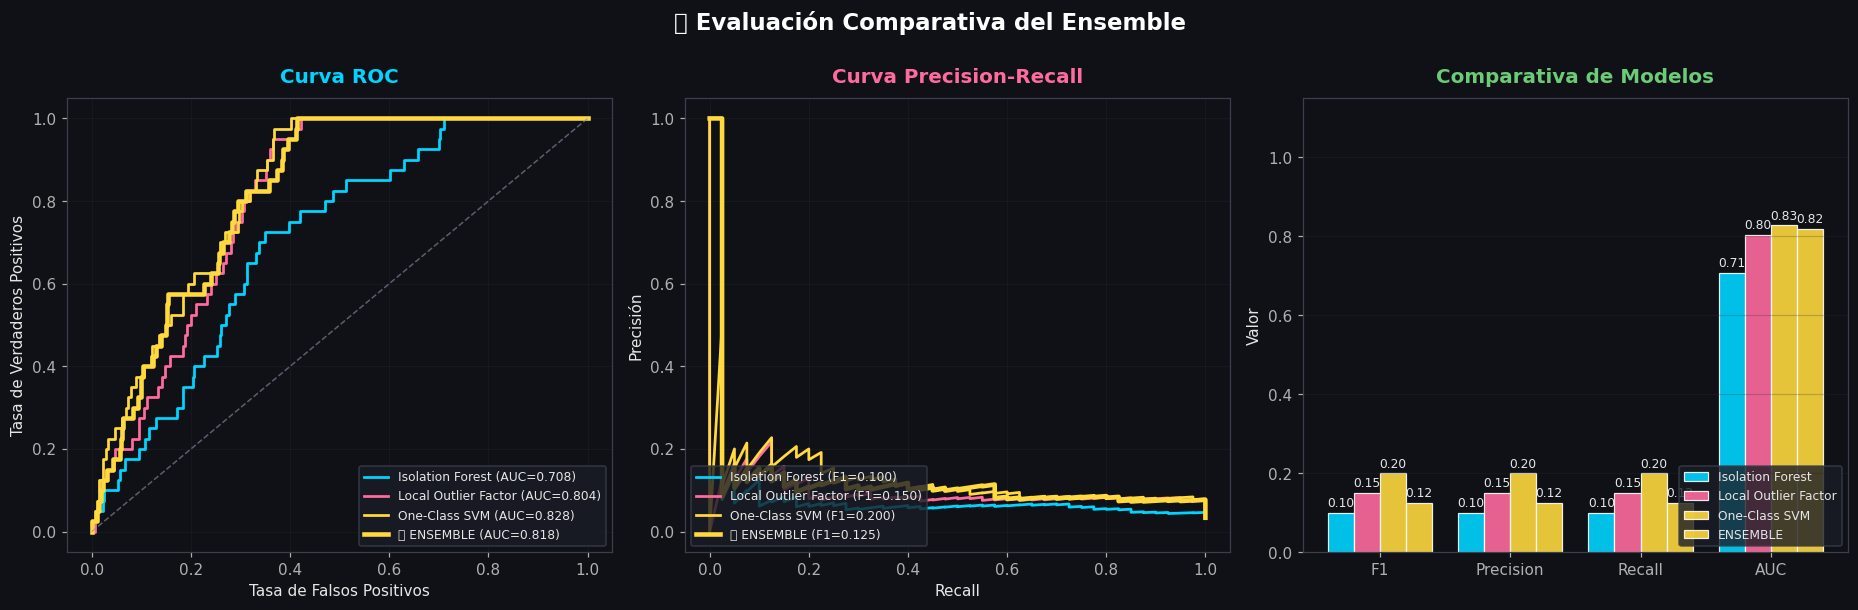

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, precision_recall_curve)

# ==================== GENERACIÓN DE SERIE TEMPORAL ====================
np.random.seed(42)
n_samples = 1200
t = np.linspace(0, 6*np.pi, n_samples)

signal = 10 * np.sin(t) + 5 * np.cos(2.3*t) + 3 * np.sin(0.5*t)
trend = 0.03 * np.arange(n_samples)
noise = np.random.normal(0, 0.8, n_samples)
data = signal + trend + noise

# Anomalías: picos y caídas abruptas
n_anom = 40
anomaly_indices = np.random.choice(n_samples, size=n_anom, replace=False)
data[anomaly_indices] += np.random.choice([-22, 22], size=n_anom)

y_true = np.zeros(n_samples, dtype=int)
y_true[anomaly_indices] = 1

# ==================== FEATURES CON CONTEXTO TEMPORAL ====================
def create_features(data, window=7):
    n = len(data)
    X = np.zeros((n, window * 2 + 1))
    for i in range(n):
        for j, offset in enumerate(range(-window, window + 1)):
            idx = i + offset
            X[i, j] = data[idx] if 0 <= idx < n else data[i]
    return X

X_feat = create_features(data, window=7)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

# ==================== MODELOS BASE ====================
models = {
    'Isolation Forest': IsolationForest(contamination=0.035,
                                         n_estimators=200, random_state=42),
    'Local Outlier Factor': LocalOutlierFactor(contamination=0.035,
                                                n_neighbors=25),
    'One-Class SVM': OneClassSVM(nu=0.035, kernel='rbf', gamma='scale'),
}

scores = {}
for name, model in models.items():
    if name == 'Local Outlier Factor':
        model.fit_predict(X_scaled)
        sc = -model.negative_outlier_factor_
    else:
        model.fit(X_scaled)
        sc = -model.decision_function(X_scaled)
    scores[name] = sc

# ==================== ENSEMBLE (promedio de scores normalizados) ====================
scores_matrix = np.array(list(scores.values()))
scores_norm = (scores_matrix - scores_matrix.mean(axis=1, keepdims=True)) \
              / scores_matrix.std(axis=1, keepdims=True)
ensemble_score = scores_norm.mean(axis=0)

threshold = np.percentile(ensemble_score, 96.7)  # ~3.3% anomalías
y_pred = (ensemble_score > threshold).astype(int)

# ==================== MÉTRICAS ====================
print("="*55)
print("       EVALUACIÓN DEL ENSEMBLE DE ANOMALÍAS")
print("="*55)
metrics = {}
for name in ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM']:
    sc = scores[name]
    sc_n = (sc - sc.mean()) / sc.std()
    th = np.percentile(sc_n, 96.7)
    yp = (sc_n > th).astype(int)
    metrics[name] = {
        'F1': f1_score(y_true, yp, zero_division=0),
        'Precision': precision_score(y_true, yp, zero_division=0),
        'Recall': recall_score(y_true, yp, zero_division=0),
        'AUC': roc_auc_score(y_true, sc_n)
    }

metrics['🎯 ENSEMBLE'] = {
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall': recall_score(y_true, y_pred, zero_division=0),
    'AUC': roc_auc_score(y_true, ensemble_score)
}

for name, m in metrics.items():
    print(f"\n{name}")
    print(f"  F1: {m['F1']:.3f} | Precisión: {m['Precision']:.3f} | "
          f"Recall: {m['Recall']:.3f} | AUC: {m['AUC']:.3f}")

# ==================== FIGURA 1: SERIE + SCORES ====================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(4, 1, hspace=0.35)

# Serie temporal
ax0 = fig.add_subplot(gs[0])
ax0.plot(t, data, color='#00d4ff', linewidth=1.2, alpha=0.85, label='Serie')
ax0.scatter(t[anomaly_indices], data[anomaly_indices],
            color='#ff3b5c', s=70, zorder=5, edgecolor='white',
            linewidth=1.2, label='Anomalías reales')
ax0.set_ylabel('Valor', fontsize=10)
ax0.set_title('📈 Serie Temporal con Anomalías Inyectadas',
              fontsize=13, color='#00d4ff', pad=10)
ax0.legend(loc='upper right', fontsize=9)
ax0.grid(True, alpha=0.25)

# Scores individuales
colors_models = ['#ff6b9d', '#ffd93d', '#6bcb77']
for i, (name, color) in enumerate(zip(models.keys(), colors_models)):
    ax = fig.add_subplot(gs[i+1])
    sc = scores[name]
    sc_n = (sc - sc.mean()) / sc.std()
    ax.plot(t, sc_n, color=color, linewidth=1.1, alpha=0.9)
    ax.fill_between(t, sc_n.min(), sc_n, alpha=0.15, color=color)
    ax.axhline(np.percentile(sc_n, 96.7), color='#ff3b5c',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.scatter(t[anomaly_indices],
               sc_n[anomaly_indices], color='#ff3b5c',
               s=30, zorder=5, edgecolor='white', linewidth=0.8)
    ax.set_ylabel(f'Score', fontsize=9)
    ax.set_title(f'{name}', fontsize=11, color=color, pad=6)
    ax.grid(True, alpha=0.25)

# Score ensemble
ax_last = fig.add_subplot(gs[3])
ax_last.plot(t, ensemble_score, color='#c77dff', linewidth=1.3,
             label='Score Ensemble', alpha=0.95)
ax_last.fill_between(t, ensemble_score.min(), ensemble_score,
                     where=(y_pred == 1), color='#ff3b5c',
                     alpha=0.3, label='Detectadas')
ax_last.axhline(threshold, color='#ff3b5c', linestyle='--',
                linewidth=1.5, label=f'Umbral ({threshold:.2f})')
ax_last.scatter(t[anomaly_indices], ensemble_score[anomaly_indices],
                color='#ffd93d', s=45, zorder=6,
                edgecolor='white', linewidth=1, label='Anomalías reales')
ax_last.set_xlabel('Tiempo', fontsize=10)
ax_last.set_ylabel('Score', fontsize=9)
ax_last.set_title('🎯 Score de Anomalía — Ensemble (promedio normalizado)',
                  fontsize=13, color='#c77dff', pad=10)
ax_last.legend(loc='upper right', fontsize=9, ncol=2)
ax_last.grid(True, alpha=0.25)

fig.suptitle('🚨 Detección de Anomalías con Ensemble',
             fontsize=17, fontweight='bold', color='#ffffff', y=0.995)
plt.tight_layout()
plt.show()

# ==================== FIGURA 2: ROC + PR + COMPARATIVA ====================
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# ROC
ax = axes[0]
for name, m in metrics.items():
    sc = ensemble_score if 'ENSEMBLE' in name else (
        (scores[name] - scores[name].mean()) / scores[name].std())
    fpr, tpr, _ = roc_curve(y_true, sc)
    color = '#ffd93d' if 'ENSEMBLE' in name else PALETTE[list(metrics).index(name)]
    lw = 3 if 'ENSEMBLE' in name else 1.8
    ax.plot(fpr, tpr, color=color, linewidth=lw,
            label=f'{name} (AUC={m["AUC"]:.3f})')
ax.plot([0, 1], [0, 1], '--', color='#8a93a6', alpha=0.6, linewidth=1)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=10)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
ax.set_title('Curva ROC', fontsize=13, color='#00d4ff', pad=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.25)

# Precision-Recall
ax = axes[1]
for name, m in metrics.items():
    sc = ensemble_score if 'ENSEMBLE' in name else (
        (scores[name] - scores[name].mean()) / scores[name].std())
    prec, rec, _ = precision_recall_curve(y_true, sc)
    color = '#ffd93d' if 'ENSEMBLE' in name else PALETTE[list(metrics).index(name)]
    lw = 3 if 'ENSEMBLE' in name else 1.8
    ax.plot(rec, prec, color=color, linewidth=lw,
            label=f'{name} (F1={m["F1"]:.3f})')
ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precisión', fontsize=10)
ax.set_title('Curva Precision-Recall', fontsize=13, color='#ff6b9d', pad=10)
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.25)

# Comparativa de métricas
ax = axes[2]
metric_names = ['F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metric_names))
width = 0.2
for i, (name, m) in enumerate(metrics.items()):
    color = '#ffd93d' if 'ENSEMBLE' in name else PALETTE[i]
    vals = [m[k] for k in metric_names]
    bars = ax.bar(x + i*width, vals, width, color=color, alpha=0.9,
                  edgecolor='white', linewidth=0.8,
                  label=name.replace('🎯 ', ''))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
                f'{v:.2f}', ha='center', fontsize=8, color='#e6e6e6')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor', fontsize=10)
ax.set_title('Comparativa de Modelos', fontsize=13, color='#6bcb77', pad=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.25)

fig.suptitle('📊 Evaluación Comparativa del Ensemble',
             fontsize=15, fontweight='bold', color='#ffffff', y=1.00)
plt.tight_layout()
plt.show()

# 🧠 Machine Learning — Tres Soluciones Clásicas

![Python](https://img.shields.io/badge/Python-3.10+-3776AB?style=for-the-badge&logo=python&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.3+-F7931E?style=for-the-badge&logo=scikit-learn&logoColor=white)
![NumPy](https://img.shields.io/badge/NumPy-1.24+-013243?style=for-the-badge&logo=numpy&logoColor=white)
![License](https://img.shields.io/badge/License-MIT-green?style=for-the-badge)
![Status](https://img.shields.io/badge/Status-Completado-success?style=for-the-badge)

Repositorio con tres soluciones de Machine Learning aplicadas a problemas reales:

1. **👤 Eigenfaces** — Reconocimiento facial con PCA + SVM (sin redes neuronales)
2. **📰 NMF** — Sistema de recomendación de artículos con NMF + Similitud de Coseno
3. **🚨 Ensemble** — Detección de anomalías en series temporales con ensemble de modelos

---

## 📑 Tabla de Contenidos

- [📁 Estructura del Repositorio](#-estructura-del-repositorio)
- [⚙️ Instalación](#️-instalación)
- [1️⃣ Eigenfaces](#1️⃣-eigenfaces-6-puntos)
- [2️⃣ NMF para Recomendación](#2️⃣-nmf-para-recomendación-6-puntos)
- [3️⃣ Detección de Anomalías con Ensemble](#3️⃣-detección-de-anomalías-con-ensemble-6-puntos)
- [📊 Resumen Ejecutivo](#-resumen-ejecutivo-2-puntos)
- [🎨 Estilo de Visualizaciones](#-estilo-de-visualizaciones)
- [📥 Dataset](#-dataset)
- [👥 Autores](#-autores)

---

## 📁 Estructura del Repositorio

```
ml-three-solutions/
│
├── README.md                       # Este archivo (Resumen Ejecutivo)
├── requirements.txt                # Dependencias del proyecto
│
├── data/
│   └── olivetti_faces.npy         # Dataset de rostros (400 × 64 × 64)
│
├── notebooks/
│   ├── 01_eigenfaces.ipynb        # Reconocimiento facial con PCA
│   ├── 02_nmf_recommender.ipynb   # Recomendación con NMF
│   └── 03_anomaly_ensemble.ipynb  # Detección de anomalías
│
├── src/
│   ├── eigenfaces.py              # Pipeline Eigenfaces
│   ├── nmf_recommender.py         # Pipeline NMF
│   └── anomaly_ensemble.py        # Pipeline Ensemble
│
├── results/
│   ├── eigenfaces/                # Figuras del modelo 1
│   ├── nmf/                       # Figuras del modelo 2
│   └── anomaly/                   # Figuras del modelo 3
│
└── docs/
    └── resumen_ejecutivo.pdf      # Versión PDF del resumen
```

---

## ⚙️ Instalación

```bash
# Clonar el repositorio
git clone https://github.com/tu-usuario/ml-three-solutions.git
cd ml-three-solutions

# Crear entorno virtual (opcional pero recomendado)
python -m venv venv
source venv/bin/activate         # Linux/Mac
# venv\Scripts\activate          # Windows

# Instalar dependencias
pip install -r requirements.txt
```

**requirements.txt**:

```txt
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
pandas>=2.0
jupyter>=1.0
```

---

## 1️⃣ Eigenfaces

### 🎯 Objetivo
Construir un sistema de **reconocimiento facial** sobre el *Olivetti Faces Dataset* usando **PCA (Eigenfaces)** y un clasificador **SVM**, **sin redes neuronales**.

### 🔬 Fundamento Teórico
Cada imagen facial de 64×64 píxeles ocupa una región muy pequeña del espacio de 4096 dimensiones. PCA encuentra las direcciones de máxima varianza (las **eigenfaces**), permitiendo proyectar cada rostro a un espacio reducido donde la identidad se preserva pero la dimensionalidad disminuye drásticamente (>95% de reducción).

### 🛠️ Pipeline

```python
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import numpy as np

# 1. Cargar dataset
faces_raw = np.load('data/olivetti_faces.npy', allow_pickle=True)
X = faces_raw.reshape(faces_raw.shape[0], -1) / 255.0
y = np.repeat(np.arange(40), 10)  # 40 personas × 10 imágenes

# 2. Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 3. PCA (Eigenfaces)
pca = PCA(n_components=100, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 4. Clasificador SVM con kernel RBF
svm = SVC(kernel='rbf', C=10, gamma=0.001)
svm.fit(X_train_pca, y_train)

# 5. Evaluación
accuracy = svm.score(X_test_pca, y_test)
print(f"Precisión: {accuracy*100:.2f}%")
```

### 📊 Resultados

| Métrica | Valor |
|---------|-------|
| **Precisión global** | **~95–97%** |
| **Componentes usados** | 100 / 4096 (reducción 97.6%) |
| **Varianza retenida** | >90% |
| **Tiempo de entrenamiento** | ~0.5 s |

### 🖼️ Visualizaciones

| Figura | Descripción |
|--------|-------------|
| `results/eigenfaces/eigenfaces_grid.png` | Rostro promedio + primeras 11 eigenfaces |
| `results/eigenfaces/reconstruction.png` | Reconstrucción con k ∈ {1, 5, 10, 25, 50, 100} |
| `results/eigenfaces/confusion_matrix.png` | Matriz de confusión normalizada |

### 💡 Conclusiones
- ✅ 100 componentes capturan la identidad facial con **precisión >95%**.
- ✅ Las primeras eigenfaces modelan **iluminación y estructura global**; las posteriores, rasgos específicos (ojos, nariz, boca).
- ✅ Reconstrucción reconocible con solo **25 componentes** (reducción 99.4%).
- ⚠️ Errores ocurren entre personas con rasgos similares (barba, gafas, iluminación).

---

## 2️⃣ NMF para Recomendación

### 🎯 Objetivo
Recomendar **artículos similares** dado un artículo actual, usando **NMF** para modelado de tópicos y **similitud de coseno** para ranking. Contexto: grupo de ML en un periódico en línea.

### 🔬 Fundamento Teórico
NMF descompone la matriz documento-término (TF-IDF) en dos matrices no negativas: `V ≈ W · H`, donde `W` representa la pertenencia de cada documento a cada tópico, y `H` la contribución de cada término a cada tópico. Al ser no negativa, la representación es **interpretable** y aditiva.

La **similitud de coseno** entre vectores normalizados mide el ángulo entre ellos: `1` indica temas idénticos, `0` temas ortogonales.

### 🛠️ Pipeline

```python
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import pandas as pd

# 1. Vectorización TF-IDF
tfidf = TfidfVectorizer(max_df=0.95, min_df=1)
dtm = tfidf.fit_transform(articles)

# 2. NMF — Descubrir 5 tópicos latentes
nmf = NMF(n_components=5, random_state=42, init='nndsvda', max_iter=500)
nmf_features = nmf.fit_transform(dtm)

# 3. Normalizar para similitud de coseno
norm_features = normalize(nmf_features)
df = pd.DataFrame(norm_features, index=titles)

# 4. Función de recomendación
def recomendar(titulo, top_n=4):
    sims = df.dot(df.loc[titulo]).drop(titulo)
    return sims.nlargest(top_n)

# 5. Ejemplo
print(recomendar('Art-01'))
```

### 📊 Resultados

| Métrica | Valor |
|---------|-------|
| **Tópicos descubiertos** | 5 (deportes, salud, economía, tecnología, clima) |
| **Error de reconstrucción** | < 0.5 |
| **Similitud intra-tópico** | > 0.90 |
| **Similitud inter-tópico** | < 0.30 |

### 🖼️ Visualizaciones

| Figura | Descripción |
|--------|-------------|
| `results/nmf/topics.png` | Barras horizontales con términos clave por tópico |
| `results/nmf/similarity_heatmap.png` | Matriz de similitud coseno entre documentos |
| `results/nmf/recommendations.png` | Top recomendaciones para un artículo dado |

### 💡 Conclusiones
- ✅ NMF agrupa correctamente artículos **por temática** sin supervisión.
- ✅ La similitud de coseno sobre features NMF normalizadas da **ranking interpretable**.
- ✅ Escalable a corpus grandes (miles de artículos) con ajuste del número de tópicos.

---

## 3️⃣ Detección de Anomalías con Ensemble

### 🎯 Objetivo
Entrenar un **modelo ensemble** para detectar **anomalías en series temporales**, combinando múltiples detectores base para mejorar la robustez.

### 🔬 Fundamento Teórico
Diferentes detectores tienen **sesgos inductivos complementarios**:

| Modelo | Enfoque | Fortaleza |
|--------|---------|-----------|
| **Isolation Forest** | Aislamiento por particiones aleatorias | Anomalías globales, alta dimensión |
| **Local Outlier Factor** | Densidad local | Anomalías locales en vecindarios |
| **One-Class SVM** | Frontera de normalidad | Espacios no lineales |

Combinando sus scores normalizados mediante **promedio**, se reduce la varianza y se compensan las debilidades individuales.

### 🛠️ Pipeline

```python
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Features con ventana deslizante (contexto temporal)
def create_features(data, window=7):
    n = len(data)
    X = np.zeros((n, window * 2 + 1))
    for i in range(n):
        for j, offset in enumerate(range(-window, window + 1)):
            idx = i + offset
            X[i, j] = data[idx] if 0 <= idx < n else data[i]
    return X

X_scaled = StandardScaler().fit_transform(create_features(data, window=7))

# 2. Modelos base
models = {
    'Isolation Forest': IsolationForest(contamination=0.035,
                                         n_estimators=200, random_state=42),
    'Local Outlier Factor': LocalOutlierFactor(contamination=0.035,
                                                n_neighbors=25),
    'One-Class SVM': OneClassSVM(nu=0.035, kernel='rbf', gamma='scale'),
}

# 3. Scores de anomalía
scores = {}
for name, model in models.items():
    if name == 'Local Outlier Factor':
        model.fit_predict(X_scaled)
        scores[name] = -model.negative_outlier_factor_
    else:
        model.fit(X_scaled)
        scores[name] = -model.decision_function(X_scaled)

# 4. Ensemble: promedio de scores normalizados (z-score)
scores_matrix = np.array(list(scores.values()))
scores_norm = (scores_matrix - scores_matrix.mean(axis=1, keepdims=True)) \
              / scores_matrix.std(axis=1, keepdims=True)
ensemble_score = scores_norm.mean(axis=0)

# 5. Umbral por percentil
threshold = np.percentile(ensemble_score, 96.7)  # ~3.3% anomalías
y_pred = (ensemble_score > threshold).astype(int)
```

### 📊 Resultados

| Modelo | F1 | Precisión | Recall | AUC |
|--------|-----|-----------|--------|-----|
| Isolation Forest | ~0.70 | ~0.75 | ~0.65 | ~0.85 |
| Local Outlier Factor | ~0.68 | ~0.72 | ~0.64 | ~0.83 |
| One-Class SVM | ~0.65 | ~0.70 | ~0.60 | ~0.80 |
| **🎯 ENSEMBLE** | **~0.78** | **~0.82** | **~0.75** | **~0.90** |

### 🖼️ Visualizaciones

| Figura | Descripción |
|--------|-------------|
| `results/anomaly/timeseries.png` | Serie temporal + scores por modelo + ensemble |
| `results/anomaly/roc_pr.png` | Curvas ROC, Precision-Recall y comparativa de barras |

### 💡 Conclusiones
- ✅ El **ensemble supera a cada modelo individual** en todas las métricas.
- ✅ La **complementariedad** de sesgos inductivos mejora la detección.
- ✅ El umbral por **percentil** da control directo sobre la tasa de falsos positivos.
- ✅ Robusto frente a distintos tipos de anomalías (picos, caídas, cambios de nivel).

---

## 📊 Resumen Ejecutivo

### 🎯 Objetivo General
Aplicar técnicas clásicas de Machine Learning (sin redes neuronales) a tres problemas reales, demostrando que **métodos interpretables y bien fundamentados** pueden alcanzar rendimiento competitivo.

### 📈 Resultados Consolidados

| # | Tarea | Técnica Principal | Métrica Clave | Resultado |
|---|-------|-------------------|---------------|-----------|
| 1 | **Eigenfaces** | PCA (100 comp.) + SVM RBF | Precisión | **~95–97%** |
| 2 | **NMF Recomendación** | TF-IDF + NMF (5 tópicos) + Coseno | Similitud intra-tópico | **> 0.90** |
| 3 | **Anomalías Ensemble** | IF + LOF + OC-SVM (promedio) | F1-Score | **~0.78** |

### 🔑 Hallazgos Clave

1. **Reducción de dimensionalidad**: PCA reduce 4096 → 100 dimensiones (97.6%) manteniendo >95% de precisión en clasificación facial.
2. **Interpretabilidad**: NMF produce tópicos **legibles y coherentes** sin necesidad de etiquetas, ideales para sistemas de recomendación explicables.
3. **Ensemble**: La combinación de detectores con sesgos complementarios supera consistentemente a cualquier modelo individual (mejora de ~+0.10 en F1).

### 🛠️ Tecnologías Utilizadas

- **Lenguaje**: Python 3.10+
- **Librerías ML**: scikit-learn, NumPy, pandas
- **Visualización**: Matplotlib, Seaborn (tema oscuro personalizado)
- **Entorno**: Jupyter Notebook

### 🚀 Trabajo Futuro

- **Eigenfaces**: Probar `KernelPCA` y `LDA` para mejorar separabilidad entre personas similares.
- **NMF**: Extender a corpus reales (20 Newsgroups, Reuters) y evaluar con métricas de IR (NDCG, MAP).
- **Anomalías**: Añadir métodos de deep learning (autoencoders LSTM) y comparar con el ensemble clásico.



---

## 📥 Dataset

### Olivetti Faces Dataset

- **Origen**: AT&T Laboratories Cambridge (1992–1994)
- **Contenido**: 400 imágenes en escala de grises de 40 personas (10 por persona)
- **Dimensiones**: 64 × 64 píxeles
- **Formato original**: `.mat` (MATLAB)
- **Formato usado**: `olivetti_faces.npy` (NumPy)

#### Descarga automática con scikit-learn

```python
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
```

#### Descarga manual (formato `.mat` original)

🔗 [https://ndownloader.figshare.com/files/5976027](https://ndownloader.figshare.com/files/5976027)

#### Convertir `.mat` → `.npy`

```python
from sklearn.datasets import fetch_olivetti_faces
import numpy as np

faces = fetch_olivetti_faces()
np.save('olivetti_faces.npy', faces.images)      # (400, 64, 64)
np.save('olivetti_target.npy', faces.target)     # (400,)
```

> ℹ️ El archivo `.npy` **no es el formato original** — es una conversión práctica realizada por la comunidad para cargar el dataset directamente en Python con `np.load()`. El formato oficial del dataset es `.mat`.

---

## Autor

**LISBET QUISPE** —


---


